In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
import glob
import copy

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset

import cv2
import numpy as np
from PIL import Image
import collections

# --- FIX FOR CIRCULAR IMPORT BUG ---
try:
    import torch._dynamo
except ImportError:
    pass

In [2]:

# -------------------- 1. DATASET (ADAPTED FOR SWIN TRANSFORMER) --------------------
class VideoDataset(Dataset):
    def __init__(self, root_dir, split='train', clip_len=32, img_size=224):
        # NOTE: img_size MUST be 224 for Swin Transformer patches
        self.root_dir = root_dir
        self.split = split
        self.clip_len = clip_len 
        self.img_size = img_size
        self.split_dir = os.path.join(root_dir, split)
        
        if not os.path.exists(self.split_dir):
            raise RuntimeError(f"Directory not found: {self.split_dir}")

        self.classes = sorted(os.listdir(self.split_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        
        self.samples = []
        for cls in self.classes:
            cls_folder = os.path.join(self.split_dir, cls)
            if not os.path.isdir(cls_folder): continue
            videos = sorted(os.listdir(cls_folder))
            for vid in videos:
                vid_path = os.path.join(cls_folder, vid)
                if os.path.isdir(vid_path): 
                    self.samples.append((vid_path, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        vid_path, label = self.samples[idx]
        frames = sorted(glob.glob(os.path.join(vid_path, "*.jpg")))
        
        if len(frames) == 0:
            return torch.zeros((3, self.clip_len, self.img_size, self.img_size)), label

        # Center Sampling (Best for Swin3D)
        if len(frames) < self.clip_len:
            frames = frames * (self.clip_len // len(frames) + 1)
            frames = frames[:self.clip_len]
        else:
            start = (len(frames) - self.clip_len) // 2
            frames = frames[start : start + self.clip_len]
        
        images = []
        for f in frames:
            try:
                img = Image.open(f).convert('RGB')
                images.append(img)
            except:
                continue

        if len(images) < self.clip_len:
             if len(images) == 0: return torch.zeros((3, self.clip_len, self.img_size, self.img_size)), label
             images = images * (self.clip_len // len(images) + 1)
             images = images[:self.clip_len]

        clip = self._transform(images)
        clip = torch.stack(clip, dim=0)
        # Swin3D expects (C, T, H, W)
        clip = clip.permute(1, 0, 2, 3) 
        
        return clip, label

    def _transform(self, images):
        # RESIZE TO 224 IS MANDATORY FOR SWIN
        images = [TF.resize(img, (self.img_size, self.img_size)) for img in images]
        
        if self.split == 'train':
            # Transformer Augmentation
            i, j, h, w = transforms.RandomCrop.get_params(images[0], output_size=(self.img_size, self.img_size))
            images = [TF.crop(img, i, j, h, w) for img in images]
            
            if torch.rand(1) < 0.5:
                brightness = 0.8 + (0.4) * torch.rand(1).item()
                images = [TF.adjust_brightness(img, brightness) for img in images]
                
            if torch.rand(1) < 0.5:
                angle = transforms.RandomRotation.get_params([-10, 10])
                images = [TF.rotate(img, angle) for img in images]
            
        else:
            images = [TF.center_crop(img, (self.img_size, self.img_size)) for img in images]
            
        images = [TF.to_tensor(img) for img in images]
        # Kinetics-400 Norm
        mean = [0.43216, 0.394666, 0.37645]
        std = [0.22803, 0.22145, 0.216989]
        images = [TF.normalize(img, mean=mean, std=std) for img in images]
        
        return images

In [3]:


# -------------------- 2. TRAINING ENGINE (SWIN TRANSFORMER) --------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 50
LEARNING_RATE = 1e-4
BATCH_SIZE = 4 # <--- REDUCED because Swin3D (224x224) is memory heavy
ROOT_DIR = '/mnt/e/SignProject/final code/frames'

def main():
    print(f"Using device: {DEVICE}")
    print("Loading Swin3D Transformer (Kinetics-400 Pretrained)...")
    
    # 1. Load Data
    train_dataset = VideoDataset(root_dir=ROOT_DIR, split='train')
    val_dataset = VideoDataset(root_dir=ROOT_DIR, split='val')
    
    # Num workers reduced to prevent RAM spikes with large images
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # 2. Load Pretrained Swin3D
    # This replaces your custom 'SignTransformer' with a standard, pretrained one
    try:
        weights = models.video.Swin3D_T_Weights.KINETICS400_V1
        model = models.video.swin3d_t(weights=weights)
    except:
        print("Warning: downloading weights manually or using non-cached version...")
        model = models.video.swin3d_t(pretrained=True)
    
    # 3. Modify Head for SLR
    # Swin3D head is accessed via 'model.head' (not model.fc)
    num_ftrs = model.head.in_features
    model.head = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_ftrs, len(train_dataset.classes))
    )
    
    # 4. Freeze/Unfreeze
    # Freeze the Patch Embeddings and early blocks
    for param in model.parameters():
        param.requires_grad = False
        
    # Unfreeze the very last block + Head
    # Swin structure is usually 'features', then 'head'
    # We unfreeze the last block of features (features[-1]) to adapt to new gestures
    for param in model.features[-1].parameters(): param.requires_grad = True
    for param in model.head.parameters(): param.requires_grad = True
    for param in model.norm.parameters(): param.requires_grad = True
    
    model = model.to(DEVICE)
    
    # 5. Optimization
    # Label Smoothing helps Transformers avoid overconfidence
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # Weight Decay is CRITICAL for Transformers (typically 0.05)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                            lr=LEARNING_RATE, weight_decay=0.05)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.5)

    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    # 6. Loop
    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss, correct, total = 0, 0, 0
        loop = tqdm(train_loader, desc=f"Ep {epoch}/{EPOCHS}")
        
        for x, y in loop:
            x, y = x.to(DEVICE), y.to(DEVICE)
            
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            
            # Gradient Clipping (Essential for Transformers)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            
            optimizer.step()
            
            train_loss += loss.item()
            _, preds = torch.max(logits, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            
            loop.set_postfix(loss=loss.item())
            
        train_acc = correct / total
        avg_train_loss = train_loss / len(train_loader)
        
        # Val
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits = model(x)
                loss = criterion(logits, y)
                val_loss += loss.item()
                _, preds = torch.max(logits, 1)
                val_correct += (preds == y).sum().item()
                val_total += y.size(0)
                
        val_acc = val_correct / val_total if val_total > 0 else 0
        avg_val_loss = val_loss / len(val_loader)
        
        print(f"Results: Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} || Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
        if val_acc > best_val_acc:
            print(f"Saving Best Swin3D Model ({val_acc:.4f})")
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_slr_swin.pth")
            
        scheduler.step(val_acc)

if __name__ == "__main__":
    main()

Using device: cuda
Loading Swin3D Transformer (Kinetics-400 Pretrained)...


Ep 1/50: 100%|██████████| 1109/1109 [04:25<00:00,  4.18it/s, loss=0.524]


Results: Train Loss: 0.8005 | Train Acc: 0.8593 || Val Loss: 0.6919 | Val Acc: 0.9149
Saving Best Swin3D Model (0.9149)


Ep 2/50: 100%|██████████| 1109/1109 [04:08<00:00,  4.47it/s, loss=0.458]


Results: Train Loss: 0.5295 | Train Acc: 0.9752 || Val Loss: 0.6729 | Val Acc: 0.9181
Saving Best Swin3D Model (0.9181)


...

Results: Train Loss: 0.4549 | Train Acc: 0.9980 || Val Loss: 0.6691 | Val Acc: 0.8973


Ep 17/50: 100%|██████████| 1109/1109 [03:33<00:00,  5.20it/s, loss=0.447]


Results: Train Loss: 0.4537 | Train Acc: 0.9993 || Val Loss: 0.6730 | Val Acc: 0.8909


Ep 18/50:   7%|▋         | 78/1109 [00:15<03:30,  4.89it/s, loss=0.448]


KeyboardInterrupt: 

In [ ]:


# --- FIX FOR CIRCULAR IMPORT BUG ---
try:
    import torch._dynamo
except ImportError:
    pass

# --- CONFIG ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 25          # Shorter run for fine-tuning
LEARNING_RATE = 1e-5 # <--- VERY LOW LR is critical for deep fine-tuning
BATCH_SIZE = 4
ROOT_DIR = '/mnt/e/SignProject/final code/frames'
PREVIOUS_BEST_MODEL = "/mnt/e/SignProject/final code/best_slr_swin.pth" # Load your 93% model

# -------------------- DATASET (Same as before) --------------------
class VideoDataset(Dataset):
    def __init__(self, root_dir, split='train', clip_len=32, img_size=224):
        self.root_dir = root_dir
        self.split = split
        self.clip_len = clip_len 
        self.img_size = img_size
        self.split_dir = os.path.join(root_dir, split)
        self.classes = sorted(os.listdir(self.split_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.samples = []
        for cls in self.classes:
            cls_folder = os.path.join(self.split_dir, cls)
            if not os.path.isdir(cls_folder): continue
            for vid in sorted(os.listdir(cls_folder)):
                path = os.path.join(cls_folder, vid)
                if os.path.isdir(path): self.samples.append((path, self.class_to_idx[cls]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        frames = sorted(glob.glob(os.path.join(path, "*.jpg")))
        if not frames: return torch.zeros((3, self.clip_len, self.img_size, self.img_size)), label

        if len(frames) < self.clip_len:
            frames = frames * (self.clip_len // len(frames) + 1)
            frames = frames[:self.clip_len]
        else:
            start = (len(frames) - self.clip_len) // 2
            frames = frames[start : start + self.clip_len]
        
        imgs = []
        for f in frames:
            try: imgs.append(Image.open(f).convert('RGB'))
            except: continue
        if not imgs: return torch.zeros((3, self.clip_len, self.img_size, self.img_size)), label
        if len(imgs) < self.clip_len:
             imgs = imgs * (self.clip_len // len(imgs) + 1)
             imgs = imgs[:self.clip_len]

        clip = self._transform(imgs)
        return torch.stack(clip).permute(1, 0, 2, 3), label

    def _transform(self, images):
        images = [TF.resize(img, (self.img_size, self.img_size)) for img in images]
        if self.split == 'train':
            i, j, h, w = transforms.RandomCrop.get_params(images[0], output_size=(self.img_size, self.img_size))
            images = [TF.crop(img, i, j, h, w) for img in images]
            if torch.rand(1) < 0.5:
                # Stronger color jitter for robustness
                brightness = 0.8 + (0.4) * torch.rand(1).item()
                contrast = 0.8 + (0.4) * torch.rand(1).item()
                images = [TF.adjust_brightness(img, brightness) for img in images]
                images = [TF.adjust_contrast(img, contrast) for img in images]
            if torch.rand(1) < 0.5:
                angle = transforms.RandomRotation.get_params([-10, 10])
                images = [TF.rotate(img, angle) for img in images]
        else:
            images = [TF.center_crop(img, (self.img_size, self.img_size)) for img in images]
        
        images = [TF.to_tensor(img) for img in images]
        mean = [0.43216, 0.394666, 0.37645]
        std = [0.22803, 0.22145, 0.216989]
        images = [TF.normalize(img, mean=mean, std=std) for img in images]
        return images

# -------------------- FINE-TUNING ENGINE --------------------
def main():
    print(f"Using device: {DEVICE}")
    print(f"Loading previous best model: {PREVIOUS_BEST_MODEL}")
    
    # 1. Load Data
    train_dataset = VideoDataset(root_dir=ROOT_DIR, split='train')
    val_dataset = VideoDataset(root_dir=ROOT_DIR, split='val')
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # 2. Rebuild Model Architecture
    try:
        weights = models.video.Swin3D_T_Weights.KINETICS400_V1
        model = models.video.swin3d_t(weights=weights)
    except:
        model = models.video.swin3d_t(pretrained=True)
    
    model.head = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(model.head.in_features, len(train_dataset.classes))
    )
    
    # 3. Load the 93% Weights
    if os.path.exists(PREVIOUS_BEST_MODEL):
        model.load_state_dict(torch.load(PREVIOUS_BEST_MODEL, map_location=DEVICE))
        print("Weights loaded successfully.")
    else:
        print("CRITICAL ERROR: Previous model not found. Using raw weights (Not recommended).")

    # 4. DEEP UNFREEZING STRATEGY
    print("Unfreezing last TWO blocks for fine-tuning...")
    for param in model.parameters():
        param.requires_grad = False
        
    # Unfreeze Head
    for param in model.head.parameters(): param.requires_grad = True
    # Unfreeze Last Block (features[-1])
    for param in model.features[-1].parameters(): param.requires_grad = True
    # Unfreeze Second to Last Block (features[-2]) <--- NEW
    for param in model.features[-2].parameters(): param.requires_grad = True
    # Unfreeze Norm layers (critical for Swin)
    for param in model.norm.parameters(): param.requires_grad = True
    
    model = model.to(DEVICE)
    
    # 5. Optimization with Cosine Schedule
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                            lr=LEARNING_RATE, weight_decay=0.05)
    
    # Cosine Annealing: Starts at lr=1e-5 and smoothly drops to 0
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_val_acc = 0.0 # Reset tracking (or set to 0.93 if you only want to save improvements)
    
    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss, correct, total = 0, 0, 0
        loop = tqdm(train_loader, desc=f"Fine-Tune Ep {epoch}/{EPOCHS}")
        
        for x, y in loop:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            train_loss += loss.item()
            _, preds = torch.max(logits, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            loop.set_postfix(loss=loss.item())
            
        train_acc = correct / total
        avg_train_loss = train_loss / len(train_loader)
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits = model(x)
                loss = criterion(logits, y)
                val_loss += loss.item()
                _, preds = torch.max(logits, 1)
                val_correct += (preds == y).sum().item()
                val_total += y.size(0)
                
        val_acc = val_correct / val_total if val_total > 0 else 0
        avg_val_loss = val_loss / len(val_loader)
        
        print(f"Results: Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} || Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
        if val_acc > best_val_acc:
            print(f"New Fine-Tuned Best ({val_acc:.4f}). Saving...")
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_slr_swin_finetuned.pth")
            
        scheduler.step()

if __name__ == "__main__":
    main()

Using device: cuda
Loading previous best model: /mnt/e/SignProject/final code/best_slr_swin.pth
Weights loaded successfully.
Unfreezing last TWO blocks for fine-tuning...


Fine-Tune Ep 1/25: 100%|██████████| 1109/1109 [03:35<00:00,  5.14it/s, loss=0.47] 


Results: Train Loss: 0.4640 | Train Acc: 0.9957 || Val Loss: 0.5974 | Val Acc: 0.9294
New Fine-Tuned Best (0.9294). Saving...


Fine-Tune Ep 2/25: 100%|██████████| 1109/1109 [03:35<00:00,  5.14it/s, loss=0.452]


Results: Train Loss: 0.4630 | Train Acc: 0.9962 || Val Loss: 0.6272 | Val Acc: 0.9149


...

Results: Train Loss: 0.4545 | Train Acc: 0.9989 || Val Loss: 0.6529 | Val Acc: 0.9037


Fine-Tune Ep 24/25: 100%|██████████| 1109/1109 [03:32<00:00,  5.22it/s, loss=0.45] 


Results: Train Loss: 0.4569 | Train Acc: 0.9968 || Val Loss: 0.6530 | Val Acc: 0.9037


Fine-Tune Ep 25/25: 100%|██████████| 1109/1109 [03:30<00:00,  5.27it/s, loss=0.448]


Results: Train Loss: 0.4542 | Train Acc: 0.9993 || Val Loss: 0.6528 | Val Acc: 0.9037


In [ ]:


# --- CONFIG ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# USE YOUR BEST MODEL (The 93.43% one)
MODEL_PATH = "/mnt/e/SignProject/final code/best_slr_swin_finetuned.pth" 
ROOT_DIR = '/mnt/e/SignProject/final code/frames'
CLIP_LEN = 32
IMG_SIZE = 224

# --- LOAD CLASSES ---
def get_classes(root_dir):
    return sorted(os.listdir(os.path.join(root_dir, 'train')))

# --- LOAD MODEL ---
def load_model(num_classes):
    print("Loading Swin3D Model...")
    try:
        weights = models.video.Swin3D_T_Weights.KINETICS400_V1
        model = models.video.swin3d_t(weights=weights)
    except:
        model = models.video.swin3d_t(pretrained=True)
        
    num_ftrs = model.head.in_features
    model.head = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_ftrs, num_classes)
    )
    
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint)
    model.to(DEVICE)
    model.eval()
    return model

def run_inference():
    classes = get_classes(ROOT_DIR)
    model = load_model(len(classes))
    
    # BUFFER: Stores the last 32 frames
    frame_buffer = collections.deque(maxlen=CLIP_LEN)
    
    # Start Webcam (Change to 'video.mp4' to test a file)
    cap = cv2.VideoCapture(0) 
    
    print(f"Model Loaded. Classes: {classes}")
    print("Press 'q' to quit.")

    current_pred = "Waiting..."
    confidence = 0.0

    while True:
        ret, frame = cap.read()
        if not ret: break
        
        # 1. Preprocess Frame for Display
        display_frame = frame.copy()
        
        # 2. Preprocess Frame for Model
        # Convert BGR -> RGB -> PIL
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(rgb_frame)
        
        # Resize & Normalize
        img_tensor = TF.resize(pil_img, (IMG_SIZE, IMG_SIZE))
        img_tensor = TF.to_tensor(img_tensor)
        img_tensor = TF.normalize(img_tensor, mean=[0.432, 0.394, 0.376], 
                                              std=[0.228, 0.221, 0.216])
        
        # Add to buffer
        frame_buffer.append(img_tensor)
        
        # 3. Predict (Only if we have 32 frames)
        if len(frame_buffer) == CLIP_LEN:
            # Stack frames: (T, C, H, W)
            clip = torch.stack(list(frame_buffer))
            # Permute for Swin: (C, T, H, W) -> Add Batch: (1, C, T, H, W)
            clip = clip.permute(1, 0, 2, 3).unsqueeze(0).to(DEVICE)
            
            with torch.no_grad():
                logits = model(clip)
                probs = torch.nn.functional.softmax(logits, dim=1)
                score, idx = torch.max(probs, 1)
                
                # Update label if confidence > 60%
                if score.item() > 0.6:
                    current_pred = classes[idx.item()]
                    confidence = score.item()
        
        # 4. Visualization
        text = f"{current_pred} ({confidence*100:.1f}%)"
        
        # Green box if confident, Red if waiting
        color = (0, 255, 0) if confidence > 0.6 else (0, 0, 255)
        
        cv2.putText(display_frame, text, (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 
                    1, color, 2, cv2.LINE_AA)
        
        # Draw a progress bar for buffer filling
        bar_width = int((len(frame_buffer) / CLIP_LEN) * 200)
        cv2.rectangle(display_frame, (30, 80), (30 + bar_width, 90), (255, 255, 0), -1)
        
        cv2.imshow('Sign Language Recognition', display_frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
            
    cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    run_inference()

Loading Swin3D Model...
Model Loaded. Classes: ['Accident', 'Dangerous', 'Dead', 'Difficult', 'Dizzy', 'I am Scared', 'Violent']
Press 'q' to quit.


[ WARN:0@7.988] global cap_v4l.cpp:982 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ERROR:0@7.988] global obsensor_uvc_stream_channel.cpp:156 getStreamChannelGroup Camera index out of range


Loading Data...
Loading Swin3D (93% Model)...
Running Evaluation...


100%|██████████| 156/156 [01:18<00:00,  1.98it/s]


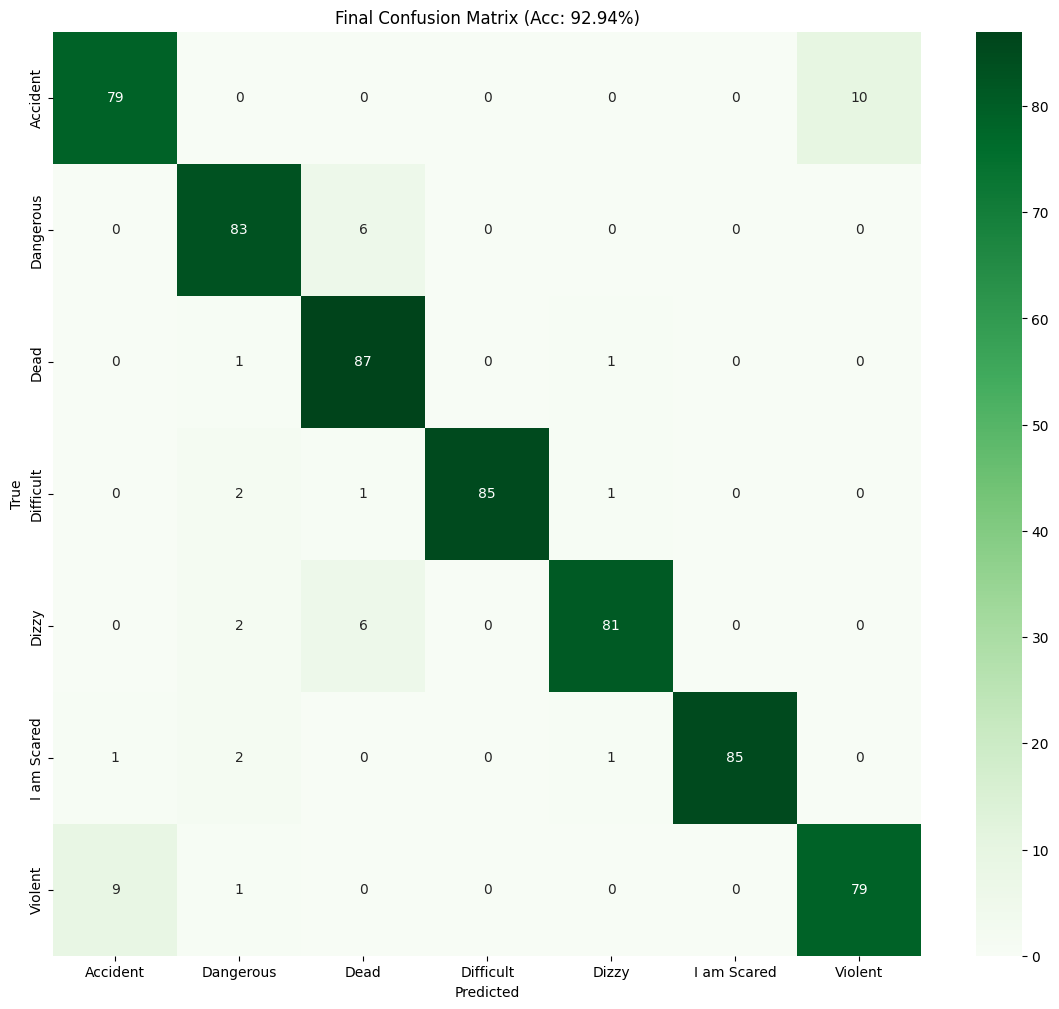


FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Accident       0.89      0.89      0.89        89
   Dangerous       0.91      0.93      0.92        89
        Dead       0.87      0.98      0.92        89
   Difficult       1.00      0.96      0.98        89
       Dizzy       0.96      0.91      0.94        89
 I am Scared       1.00      0.96      0.98        89
     Violent       0.89      0.89      0.89        89

    accuracy                           0.93       623
   macro avg       0.93      0.93      0.93       623
weighted avg       0.93      0.93      0.93       623



In [ ]:


# --- CONFIG ---
MODEL_PATH = "/mnt/e/SignProject/final code/best_slr_swin_finetuned.pth" # Using your 93% model
ROOT_DIR = '/mnt/e/SignProject/final code/frames'
BATCH_SIZE = 4
IMG_SIZE = 224
CLIP_LEN = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class VideoDataset(Dataset):
    def __init__(self, root_dir, split='val'):
        self.split_dir = os.path.join(root_dir, split)
        self.classes = sorted(os.listdir(self.split_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.samples = []
        for cls in self.classes:
            cls_folder = os.path.join(self.split_dir, cls)
            if not os.path.isdir(cls_folder): continue
            for vid in sorted(os.listdir(cls_folder)):
                path = os.path.join(cls_folder, vid)
                if os.path.isdir(path): self.samples.append((path, self.class_to_idx[cls]))

    def __len__(self): return len(self.samples)
    
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        frames = sorted(glob.glob(os.path.join(path, "*.jpg")))
        if not frames: return torch.zeros((3, CLIP_LEN, IMG_SIZE, IMG_SIZE)), label
        
        # Center Sampling
        if len(frames) < CLIP_LEN:
            frames = frames * (CLIP_LEN // len(frames) + 1)
            frames = frames[:CLIP_LEN]
        else:
            start = (len(frames) - CLIP_LEN) // 2
            frames = frames[start : start + CLIP_LEN]
            
        imgs = []
        for f in frames:
            try: imgs.append(Image.open(f).convert('RGB'))
            except: continue
        
        if not imgs: return torch.zeros((3, CLIP_LEN, IMG_SIZE, IMG_SIZE)), label
        
        # Transforms
        imgs = [TF.resize(img, (IMG_SIZE, IMG_SIZE)) for img in imgs]
        imgs = [TF.to_tensor(img) for img in imgs]
        imgs = [TF.normalize(img, mean=[0.432, 0.394, 0.376], std=[0.228, 0.221, 0.216]) for img in imgs]
        
        return torch.stack(imgs).permute(1, 0, 2, 3), label

def analyze():
    print("Loading Data...")
    val_dataset = VideoDataset(ROOT_DIR, split='val')
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    print("Loading Swin3D (93% Model)...")
    try:
        weights = models.video.Swin3D_T_Weights.KINETICS400_V1
        model = models.video.swin3d_t(weights=weights)
    except:
        model = models.video.swin3d_t(pretrained=True)
        
    model.head = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.head.in_features, len(val_dataset.classes))
    )
    
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    
    y_true, y_pred = [], []
    print("Running Evaluation...")
    
    with torch.no_grad():
        for x, y in tqdm(val_loader):
            x = x.to(DEVICE)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            
    # Plot
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=val_dataset.classes, yticklabels=val_dataset.classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Final Confusion Matrix (Acc: {100*sum(1 for x,y in zip(y_true,y_pred) if x==y)/len(y_true):.2f}%)')
    plt.savefig('final_confusion_matrix.png')
    plt.show()
    
    print("\n" + "="*30)
    print("FINAL CLASSIFICATION REPORT")
    print("="*30)
    print(classification_report(y_true, y_pred, target_names=val_dataset.classes))

if __name__ == "__main__":
    analyze()